# Principal Component Analysis (PCA) analysis on treasury yield curve

### 1. Imports
Imports the necessary libraries.

### 2. Data Loading & Preprocessing
Data processing daily treasury yield curve rates from a CSV (`daily-treasury-rates.csv`).

### 3. Rolling PCA Implementation
Performs PCA analysis on treasury yield curve
- Normalize data by calculating daily yield changes.
- Apply Principal Component Analysis (PCA) on rolling basis and incorporate window and exponential decay weight.
- Identifies and standardizes the first 3 principal components as **Level, Slope, and Curvature**.
- Projects the out-of-sample scores and returns structured DataFrames for loadings, scores, and explained variance.

### 4. PnL Attribution analysis from PCA
Performs PnL Attribution analysis on the impact of Level, Slope and Curvature given a set of random fixed-income portfolios.

### 5. VaR analysis from PCA
Evaluates Value at Risk (VaR) from Level, Slope and Curvature factors given a set of random fixed-income portfolios.

### 6. Hypertunning PCA performance
Performs grid search on finding the best rolling PCA window and decay factor that stablies factor loadings over time.


In [35]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from IPython.display import display
import itertools
from scipy.stats import zscore

In [36]:
def process_treasury_data(file_path="daily-treasury-rates.csv"):
    """Loads and standardizes treasury rate data, returning a DataFrame."""
    def std_col(col):
        if col.strip().lower() == "date": return "Date"
        mo = re.match(r"^\s*([\d.]+)\s*(?:Mo(?:nth)?|M)\s*$", col, re.IGNORECASE)
        if mo: return f"{mo.group(1)}M"
        yr = re.match(r"^\s*([\d.]+)\s*(?:Yr(?:s|ear)?|Y)\s*$", col, re.IGNORECASE)
        if yr: return f"{yr.group(1)}Y"
        return col.strip()
    df = pd.read_csv(file_path, parse_dates=["Date"]).rename(columns=std_col)
    df = df.set_index("Date").sort_index()
    return df
    
df = process_treasury_data()
df.head()


# df_pct = df.diff().dropna(how='all')
# df_pct.head()

,1M,1.5M,2M,3M,4M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,,,,,
2010-01-04,0.05,NaN,NaN,0.08,NaN,0.18,0.45,1.09,1.66,2.65,3.36,3.85,4.60,4.65
2010-01-05,0.03,NaN,NaN,0.07,NaN,0.17,0.41,1.01,1.57,2.56,3.28,3.77,4.54,4.59
2010-01-06,0.03,NaN,NaN,0.06,NaN,0.15,0.40,1.01,1.60,2.60,3.33,3.85,4.63,4.70
2010-01-07,0.02,NaN,NaN,0.05,NaN,0.16,0.40,1.03,1.62,2.62,3.33,3.85,4.62,4.69
2010-01-08,0.02,NaN,NaN,0.05,NaN,0.15,0.37,0.96,1.56,2.57,3.31,3.83,4.61,4.70


In [37]:
# Calculate exponential decay factor corresponding to a target Effective Sample Size (ESS)
def decay_from_target_ess(target_ess):
    r = (target_ess - 1) / (target_ess + 1)
    return r

# Compute Kish's Effective Sample Size for exponential weighting
def effective_sample_size(window, decay):
    weights = decay ** np.arange(window - 1, -1, -1)
    weights /= weights.sum()
    return (weights.sum() ** 2) / (weights ** 2).sum()


def apply_rolling_pca(df, tenors=None, window=252, decay=None, target_ess=None):
    if tenors is None:
        tenors = ['3M', '6M', '1Y', '2Y', '5Y', '10Y', '30Y']

    # Resolve decay factor: prioritize target_ess if specified, otherwise fallback
    if target_ess is not None:
        target_ess = min(target_ess, window)  # target_ess cannot exceed window
        decay = decay_from_target_ess(target_ess)
    elif decay is None:
        decay = 0.99  # Fallback default

    # Get daily changes and drop rows with missing data for complete tensor alignment
    daily_changes = df[tenors].diff().dropna() * 100
    dates = daily_changes.index[window:]
    n_days = len(dates)
    n_tenors = len(tenors)

    # Pre-allocate numpy arrays for significant performance boost
    loadings = np.zeros((n_days, 3, n_tenors))
    scores = np.zeros((n_days, 3))
    explained_variance = np.zeros((n_days, 3))

    # Pre-calculate decay weights once
    weights = decay ** np.arange(window - 1, -1, -1)
    weights /= weights.sum()
    sqrt_weights = np.sqrt(weights)[:, None]

    # Verify and display ESS configuration
    # ess_check = effective_sample_size(window, decay)
    # print(f"[Config Check] window={window}, decay={decay:.6f}, "
    #       f"ESS≈{ess_check:.1f} days")

    # Extract underlying numpy array to bypass pandas indexing overhead in the loop
    data_vals = daily_changes.values
    pca = PCA(n_components=3)

    for idx in range(n_days):
        i = idx + window
        # Get window data and apply weights, shape: (window, n_tenors)
        window_data = data_vals[i - window:i]
        pca.fit(window_data * sqrt_weights)

        raw_pcs = pca.components_[:3].copy()

        if idx == 0:
            # Day 0: Identify components by curve shape as [Level, Slope, Curvature]
            pc_level = max(raw_pcs, key=lambda x: abs(x.mean()))
            pc_slope = max(
                [p for p in raw_pcs if not np.array_equal(p, pc_level)],
                key=lambda x: abs(x[-1] - x[0])
            )
            pc_curve = next(
                p for p in raw_pcs
                if not np.array_equal(p, pc_level) and not np.array_equal(p, pc_slope)
            )
            pcs = np.array([pc_level, pc_slope, pc_curve])

            # Standardize initial signs (Level positive, Slope rising, Curvature bowing)
            if pcs[0].mean() < 0:
                pcs[0] *= -1
            if pcs[1, -1] < pcs[1, 0]:
                pcs[1] *= -1
            if pcs[2, n_tenors // 2] > 0:
                pcs[2] *= -1

        else:
            # Subsequent days: track components over time via Hungarian algorithm
            prev_pcs = loadings[idx - 1]
            similarity = np.abs(raw_pcs @ prev_pcs.T)
            
            # Solve optimal bipartite matching to prevent component switching
            row_ind, col_ind = linear_sum_assignment(-similarity)

            # Reorder components to match previous day's assignment
            reordered = np.zeros_like(raw_pcs)
            for r, c in zip(row_ind, col_ind):
                reordered[c] = raw_pcs[r]
            pcs = reordered

            # Flip sign if angle > 90° (negative dot product) to preserve continuity
            for j in range(3):
                if np.dot(pcs[j], prev_pcs[j]) < 0:
                    pcs[j] *= -1

        loadings[idx] = pcs

        # Out-of-sample projection using dot product
        raw_dy_today = data_vals[i]
        scores[idx] = raw_dy_today @ pcs.T
        explained_variance[idx] = pca.explained_variance_ratio_

    # Return structured DataFrames cleanly
    pc1_df = pd.DataFrame(loadings[:, 0, :], index=dates, columns=tenors)
    pc2_df = pd.DataFrame(loadings[:, 1, :], index=dates, columns=tenors)
    pc3_df = pd.DataFrame(loadings[:, 2, :], index=dates, columns=tenors)

    scores_df = pd.DataFrame(scores, index=dates, columns=['PC1', 'PC2', 'PC3'])
    exp_var_df = pd.DataFrame(explained_variance, index=dates, columns=['PC1', 'PC2', 'PC3'])

    return pc1_df, pc2_df, pc3_df, scores_df, exp_var_df


level = 95
optimized = 1  # switch

if optimized:
    window = 252 * 3
    target_ess = 252 * 3
else:
    window = 252 * 3
    target_ess = 252 * 1

# Retrieve nicely structured outputs
pc1_loadings_df, pc2_loadings_df, pc3_loadings_df, scores_df, exp_var_df = apply_rolling_pca(
    df, window=window, target_ess=target_ess
)

# PCA Checks
exp_var_df['Total'] = exp_var_df[['PC1', 'PC2', 'PC3']].sum(axis=1)
passed_series = exp_var_df['Total'] >= (level / 100)
print(f"Passed Ratio: {passed_series.mean():.2%} for {level}% info on a rolling {window}-day basis.")
exp_var_df.head()

Passed Ratio: 59.35% for 95% info on a rolling 756-day basis.


,PC1,PC2,PC3,Total
Date,,,,
2013-01-11,0.865237,0.078236,0.021668,0.965141
2013-01-14,0.865341,0.078112,0.021641,0.965095
2013-01-15,0.865267,0.078097,0.021668,0.965032
2013-01-16,0.865345,0.078001,0.021701,0.965046
2013-01-17,0.865536,0.077777,0.021670,0.964982


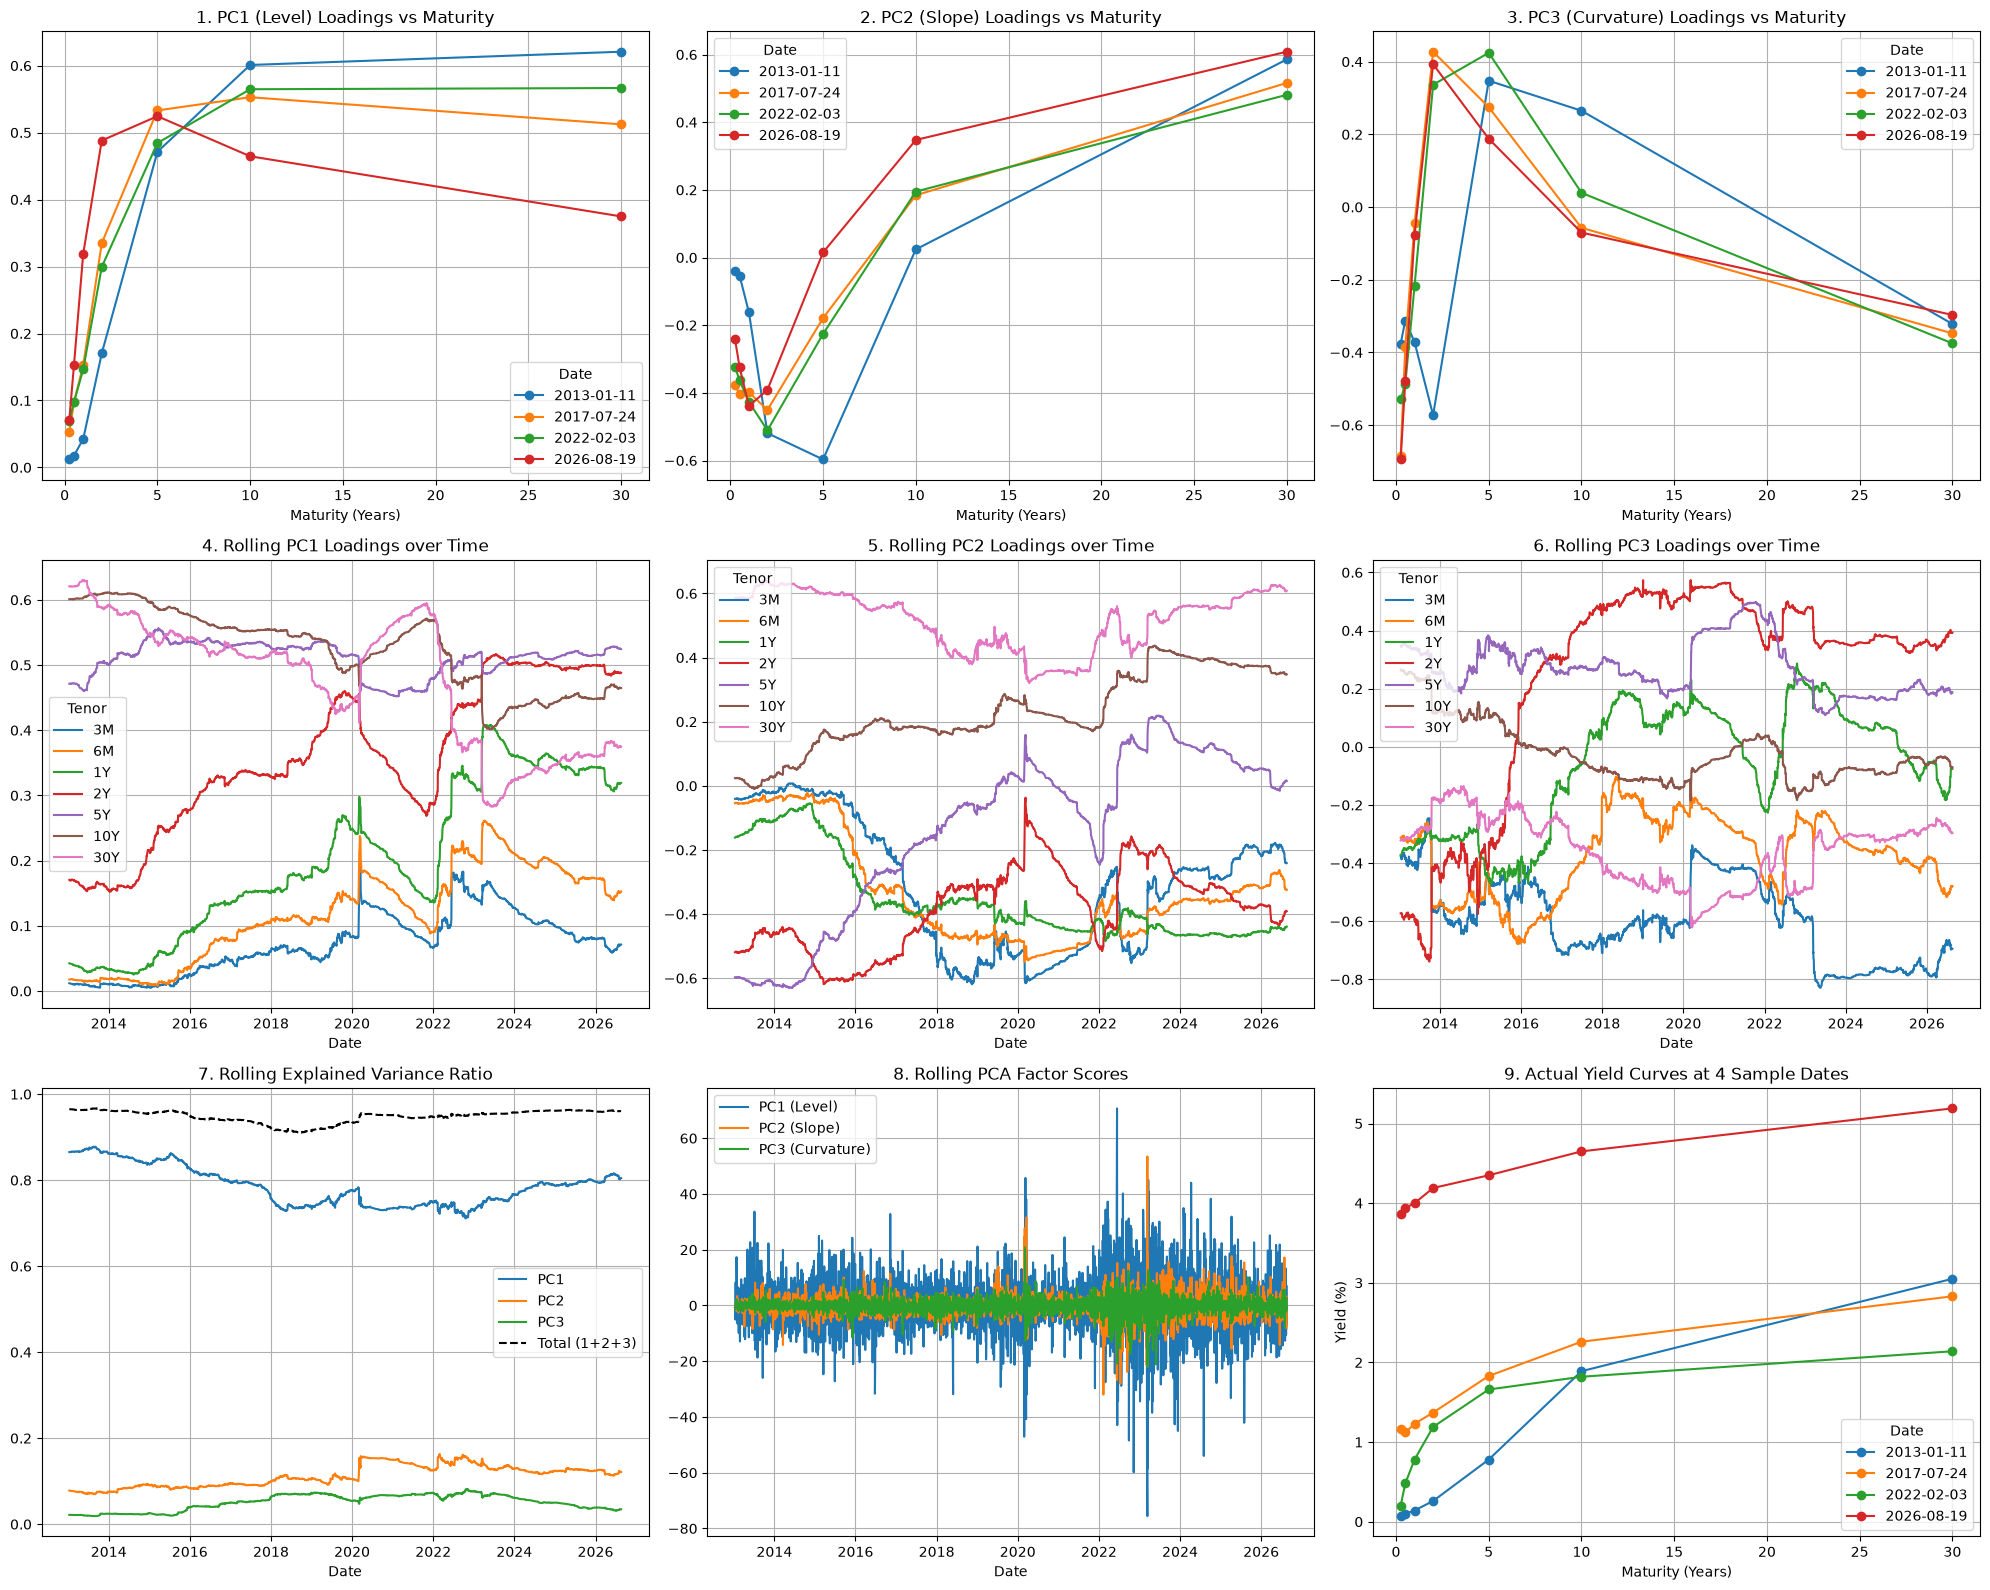

In [38]:
tenors = ['3M', '6M', '1Y', '2Y', '5Y', '10Y', '30Y']

def tenor_to_years(col):
    if col.endswith('M'): return float(col[:-1]) / 12
    elif col.endswith('Y'): return float(col[:-1])
    return None

numeric_tenors = [tenor_to_years(t) for t in tenors]
dates = exp_var_df.index

# Elegantly pick 4 evenly spaced sample dates
if len(dates) >= 4:
    idx = np.linspace(0, len(dates) - 1, 4, dtype=int)
    sample_dates = dates[idx]
else:
    sample_dates = dates
fig, axs = plt.subplots(3, 3, figsize=(20, 16))
# Row 1: Loadings vs Maturity
for date in sample_dates:
    label = date.strftime('%Y-%m-%d')
    axs[0, 0].plot(numeric_tenors, pc1_loadings_df.loc[date], marker='o', label=label)
    axs[0, 1].plot(numeric_tenors, pc2_loadings_df.loc[date], marker='o', label=label)
    axs[0, 2].plot(numeric_tenors, pc3_loadings_df.loc[date], marker='o', label=label)
axs[0, 0].set_title("1. PC1 (Level) Loadings vs Maturity")
axs[0, 1].set_title("2. PC2 (Slope) Loadings vs Maturity")
axs[0, 2].set_title("3. PC3 (Curvature) Loadings vs Maturity")
for ax in axs[0, :]:
    ax.set_xlabel("Maturity (Years)")
    ax.legend(title="Date")
    ax.grid(True)
# Row 2: Rolling Loadings Stability
for t in tenors:
    axs[1, 0].plot(pc1_loadings_df.index, pc1_loadings_df[t], label=t)
    axs[1, 1].plot(pc2_loadings_df.index, pc2_loadings_df[t], label=t)
    axs[1, 2].plot(pc3_loadings_df.index, pc3_loadings_df[t], label=t)
axs[1, 0].set_title("4. Rolling PC1 Loadings over Time")
axs[1, 1].set_title("5. Rolling PC2 Loadings over Time")
axs[1, 2].set_title("6. Rolling PC3 Loadings over Time")
for ax in axs[1, :]:
    ax.set_xlabel("Date")
    ax.legend(title="Tenor")
    ax.grid(True)
# Row 3: Explained Variance, Factor Scores, and Raw Yield Curves
axs[2, 0].plot(exp_var_df.index, exp_var_df['PC1'], label='PC1')
axs[2, 0].plot(exp_var_df.index, exp_var_df['PC2'], label='PC2')
axs[2, 0].plot(exp_var_df.index, exp_var_df['PC3'], label='PC3')
axs[2, 0].plot(exp_var_df.index, exp_var_df['Total'], label='Total (1+2+3)', color='black', linestyle='--')
axs[2, 0].set_title("7. Rolling Explained Variance Ratio")
axs[2, 0].set_xlabel("Date")
axs[2, 0].legend()
axs[2, 0].grid(True)
axs[2, 1].plot(scores_df.index, scores_df['PC1'], label='PC1 (Level)')
axs[2, 1].plot(scores_df.index, scores_df['PC2'], label='PC2 (Slope)')
axs[2, 1].plot(scores_df.index, scores_df['PC3'], label='PC3 (Curvature)')
axs[2, 1].set_title("8. Rolling PCA Factor Scores")
axs[2, 1].set_xlabel("Date")
axs[2, 1].legend()
axs[2, 1].grid(True)
for date in sample_dates:
    label = date.strftime('%Y-%m-%d')
    axs[2, 2].plot(numeric_tenors, df.loc[date, tenors], marker='o', label=label)
axs[2, 2].set_title("9. Actual Yield Curves at 4 Sample Dates")
axs[2, 2].set_xlabel("Maturity (Years)")
axs[2, 2].set_ylabel("Yield (%)")
axs[2, 2].legend(title="Date")
axs[2, 2].grid(True)
plt.tight_layout()
plt.show()

In [39]:
dv01_sets = {
    "1. Level (outright duration)": pd.Series(
        [200, 200, 200, 200, 200, 200, 200], index=tenors),
    "2. Slope (2s10s steepener)": pd.Series(
        [0, 0, 0, 1000, 0, -1000, 0], index=tenors),
    "3. Curvature (2s5s10s butterfly)": pd.Series(
        [0, 0, 0, 500, -1000, 500, 0], index=tenors),
    "4. Asymmetric multi-point butterfly": pd.Series(
        [0, 0, 1000, 0, 500, -800, -100], index=tenors),
    "5. High-frequency alternating (sawtooth)": pd.Series(
        [1000, -1000, 1000, -1000, 1000, -1000, 1000], index=tenors),
}

# Re-align daily changes with the days we ran the out-of-sample PCA on
daily_changes_bps = df[tenors].diff().dropna() * 100
daily_changes_bps = daily_changes_bps.loc[scores_df.index]

attribution_results = {}

for name, dv01 in dv01_sets.items():
    # Fully vectorized computation across the entire time series for factor sensitivities
    factor_dv01_pc1 = pc1_loadings_df.dot(dv01)
    factor_dv01_pc2 = pc2_loadings_df.dot(dv01)
    factor_dv01_pc3 = pc3_loadings_df.dot(dv01)
    
    # Fully vectorized PnL attribution
    pnl_attribution = pd.DataFrame({
        'PC1 (Level) PnL': -factor_dv01_pc1 * scores_df['PC1'],
        'PC2 (Slope) PnL': -factor_dv01_pc2 * scores_df['PC2'],
        'PC3 (Curvature) PnL': -factor_dv01_pc3 * scores_df['PC3'],
    }, index=scores_df.index).round(2)
    
    pnl_attribution['Total PCA PnL'] = pnl_attribution.sum(axis=1)
    
    # Validation: Actual PnL and unexplained Residual
    pnl_attribution['Actual PnL'] = -(daily_changes_bps @ dv01)
    pnl_attribution['Residual'] = pnl_attribution['Actual PnL'] - pnl_attribution['Total PCA PnL']
    
    attribution_results[name] = pnl_attribution
    
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    pnl_attribution = pnl_attribution.round(2)
    display(pnl_attribution.head()) # Use `display()` if running inside Jupyter for pretty tables



1. Level (outright duration)


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,1546.52,-99.44,-170.76,1276.32,1200.0,-76.32
2013-01-14,-11.34,-14.41,-186.60,-212.35,-400.0,-187.65
2013-01-15,1961.40,-11.59,-337.21,1612.60,1600.0,-12.60
2013-01-16,709.88,-90.13,47.79,667.54,800.0,132.46
2013-01-17,-3220.45,-51.65,93.18,-3178.92,-3000.0,178.92



2. Slope (2s10s steepener)


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,-1720.23,-354.27,-532.99,-2607.49,-2000.0,607.49
2013-01-14,12.63,-51.20,-579.85,-618.42,-0.0,618.42
2013-01-15,-2183.79,-41.29,-1045.26,-3270.34,-3000.0,270.34
2013-01-16,-790.83,-321.00,147.76,-964.07,-2000.0,-1035.93
2013-01-17,3589.65,-183.86,286.86,3692.65,3000.0,-692.65



3. Curvature (2s5s10s butterfly)


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,-342.00,227.79,-319.04,-433.25,-1000.0,-566.75
2013-01-14,2.51,33.11,-346.83,-311.21,-0.0,311.21
2013-01-15,-434.76,26.70,-624.85,-1032.91,-1500.0,-467.09
2013-01-16,-157.72,207.58,88.66,138.52,1000.0,861.48
2013-01-17,714.92,119.78,171.75,1006.45,500.0,-506.45



4. Asymmetric multi-point butterfly


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,-1057.62,-350.72,-240.30,-1648.64,-900.0,748.64
2013-01-14,7.77,-50.73,-261.24,-304.20,-0.0,304.20
2013-01-15,-1342.37,-40.89,-471.27,-1854.53,-1200.0,654.53
2013-01-16,-485.91,-317.99,66.39,-737.51,-1700.0,-962.49
2013-01-17,2206.00,-182.48,129.28,2152.80,2500.0,347.20



5. High-frequency alternating (sawtooth)


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,1428.18,219.04,-64.71,1582.51,2000.0,417.49
2013-01-14,-10.48,31.74,-70.79,-49.53,-0.0,49.53
2013-01-15,1812.07,25.59,-128.79,1708.87,2000.0,291.13
2013-01-16,656.06,198.73,18.19,872.98,0.0,-872.98
2013-01-17,-2976.92,113.72,36.06,-2827.14,-1000.0,1827.14


In [40]:
# Pure N-day Historical VaR method (Empirical Rolling Sum - Vectorized)
N = 10

# 1. Pre-compute N-day rolling shocks for all 3 PCs simultaneously.
# Extract as a numpy array for maximum speed. Shape: (num_days, 3)
n_day_shocks = scores_df[['PC1', 'PC2', 'PC3']].rolling(window=N).sum().dropna().values

# 2. Extract today's latest loadings as a single (3, 7) matrix
loadings_today = np.array([
    pc1_loadings_df.iloc[-1],
    pc2_loadings_df.iloc[-1],
    pc3_loadings_df.iloc[-1]
])

print(f"--- 95% {N}-Day Pure Historical Component VaR ---")

# 3. Vectorized Portfolio Loop
for name, dv01 in dv01_sets.items():
    
    # A. Today's Factor DV01s (Matrix Multiplication)
    # Shape: (3, 7) matrix @ (7,) vector -> (3,) array [DV01_PC1, DV01_PC2, DV01_PC3]
    factor_dv01s_today = loadings_today @ dv01.values
    
    # B. Simulate historical PnL components (Numpy Broadcasting)
    # Shape: (num_days, 3) * (3,) -> (num_days, 3) 
    sim_pnl_components = -n_day_shocks * factor_dv01s_today
    
    # C. Calculate Total PnL (Sum across the 3 PCs for each simulated day)
    sim_total_pnl = sim_pnl_components.sum(axis=1)
    
    # D. Calculate N-Day VaR (5th percentile)
    # axis=0 computes the percentile for PC1, PC2, and PC3 all at once instantly
    var_95_components = np.percentile(sim_pnl_components, 5, axis=0) 
    var_95_total = np.percentile(sim_total_pnl, 5)
    
    # E. Print results
    print(f"\n{name}")
    print(f"Total VaR: ${abs(var_95_total):,.2f}")
    print(f"PC1: ${abs(var_95_components[0]):,.2f} | "
          f"PC2: ${abs(var_95_components[1]):,.2f} | "
          f"PC3: ${abs(var_95_components[2]):,.2f}")


--- 95% 10-Day Pure Historical Component VaR ---

1. Level (outright duration)
Total VaR: $25,790.64
PC1: $24,716.19 | PC2: $1,899.68 | PC3: $3,080.35

2. Slope (2s10s steepener)
Total VaR: $15,620.23
PC1: $1,211.65 | PC2: $16,549.75 | PC3: $5,253.46

3. Curvature (2s5s10s butterfly)
Total VaR: $2,322.22
PC1: $2,208.13 | PC2: $826.89 | PC3: $395.52

4. Asymmetric multi-point butterfly
Total VaR: $20,109.19
PC1: $8,886.88 | PC2: $17,255.62 | PC3: $1,178.34

5. High-frequency alternating (sawtooth)
Total VaR: $14,691.05
PC1: $9,518.63 | PC2: $5,819.77 | PC3: $10,767.58


In [41]:
def compute_oos_explained_variance(daily_changes_vals, loadings):
    """
    Computes out-of-sample R2 using yesterday's loadings on today's returns.
    """
    n_days = loadings.shape[0]
    oos_r2 = np.full(n_days, np.nan)

    for idx in range(1, n_days):
        prev_pcs = loadings[idx - 1]           # Loadings fit up to yesterday
        today_change = daily_changes_vals[idx] # Actual return today (out-of-sample)

        total_var = np.sum(today_change ** 2)
        if total_var < 1e-12:
            continue

        # Project today's return onto yesterday's PCs and evaluate reconstruction error
        proj_scores = today_change @ prev_pcs.T
        reconstructed = proj_scores @ prev_pcs
        residual_var = np.sum((today_change - reconstructed) ** 2)

        oos_r2[idx] = 1 - (residual_var / total_var)

    return oos_r2


def optimize_pca_params(
    df,
    windows=[60, 126, 252, 500],
    target_esses=[30, 60, 126, 252],
    expl_threshold=0.95,
    stability_weight=1.0,
    tenors=None,
):
    """
    Grid searches PCA parameters balancing OOS explanatory power and loading stability.
    """
    valid_combos = [
        (w, ess) for w, ess in itertools.product(windows, target_esses)
        if ess <= w
    ]

    results = []

    for w, ess in valid_combos:
        pc1_df, pc2_df, pc3_df, scores_df, exp_var_df = apply_rolling_pca(
            df, tenors=tenors, window=w, target_ess=ess
        )

        # In-sample explanatory power
        exp_var_df['Total'] = exp_var_df[['PC1', 'PC2', 'PC3']].sum(axis=1)
        mean_expl_var_in_sample = exp_var_df['Total'].mean()

        # Out-of-sample explanatory power
        loadings_stack = np.stack([
            pc1_df.values, pc2_df.values, pc3_df.values
        ], axis=1)

        tenor_cols = tenors if tenors is not None else \
            ['3M', '6M', '1Y', '2Y', '5Y', '10Y', '30Y']
        daily_changes_full = (df[tenor_cols].diff().dropna() * 100).loc[pc1_df.index]

        oos_r2 = compute_oos_explained_variance(daily_changes_full.values, loadings_stack)
        mean_oos_r2 = np.nanmean(oos_r2)

        # Overfitting gap (in-sample vs out-of-sample)
        overfit_gap = mean_expl_var_in_sample - mean_oos_r2

        # Loading instability penalty
        pc1_instability = pc1_df.diff().abs().mean().mean()
        pc2_instability = pc2_df.diff().abs().mean().mean()
        instability_score = (pc1_instability + pc2_instability) * 1000

        implied_decay = decay_from_target_ess(ess)

        results.append({
            'Window': w,
            'Target ESS': ess,
            'Implied Decay': round(implied_decay, 5),
            'In-Sample Expl Var': round(mean_expl_var_in_sample, 4),
            'OOS Expl Var': round(mean_oos_r2, 4),
            'Overfit Gap': round(overfit_gap, 4),
            'Instability Penalty': round(instability_score, 4),
        })

    results_df = pd.DataFrame(results)

    # Standardize metrics via z-score and compute combined score
    oos_z = zscore(results_df['OOS Expl Var'])
    instab_z = zscore(results_df['Instability Penalty'])
    results_df['Combined Score'] = oos_z - stability_weight * instab_z

    results_df = results_df.sort_values(
        by='Combined Score', ascending=False
    ).reset_index(drop=True)

    return results_df


def plot_pareto_frontier(results_df):
    """
    Plots the Pareto frontier comparing loading stability against OOS explanatory power.
    """
    df_sorted = results_df.sort_values('Instability Penalty').reset_index(drop=True)

    # Identify Pareto-optimal points
    is_pareto = np.zeros(len(df_sorted), dtype=bool)
    max_oos_so_far = -np.inf
    for i in range(len(df_sorted)):
        oos = df_sorted.loc[i, 'OOS Expl Var']
        if oos > max_oos_so_far:
            is_pareto[i] = True
            max_oos_so_far = oos

    # Plot frontier
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        df_sorted.loc[~is_pareto, 'Instability Penalty'],
        df_sorted.loc[~is_pareto, 'OOS Expl Var'],
        color='lightgray', label='Dominated'
    )
    ax.scatter(
        df_sorted.loc[is_pareto, 'Instability Penalty'],
        df_sorted.loc[is_pareto, 'OOS Expl Var'],
        color='red', s=80, label='Pareto Frontier'
    )

    # Annotate Pareto candidates
    for i in np.where(is_pareto)[0]:
        row = df_sorted.loc[i]
        ax.annotate(
            f"W={int(row['Window'])}, ESS={int(row['Target ESS'])}",
            (row['Instability Penalty'], row['OOS Expl Var']),
            textcoords="offset points", xytext=(5, 5), fontsize=8
        )

    ax.set_xlabel('Instability Penalty (Lower is better)')
    ax.set_ylabel('OOS Expl Var (Higher is better)')
    ax.set_title('Stability vs. OOS Explanatory Power (Pareto Frontier)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('pareto_frontier.png', dpi=120)
    plt.show()

    return df_sorted[is_pareto].sort_values('Instability Penalty')


# --- Grid Search & Display ---
test_windows = [90, 126, 180, 1 * 252, 2 * 252, 3 * 252, 5 * 252]
test_target_esses = [60, 126, 252, 2 * 252, 3 * 252]

optimization_results = optimize_pca_params(
    df,
    windows=test_windows,
    target_esses=test_target_esses,
    expl_threshold=0.95,
    stability_weight=1.0,
)

# Display top 10 ranked parameter sets
display(optimization_results.head(10))

,Window,Target ESS,Implied Decay,In-Sample Expl Var,OOS Expl Var,Overfit Gap,Instability Penalty,Combined Score
0,252,252,0.99209,0.9515,0.8702,0.0814,5.9287,2.461830
1,180,126,0.98425,0.9525,0.8698,0.0828,9.6479,1.729431
2,252,126,0.98425,0.9521,0.8695,0.0826,10.3666,1.439039
3,126,126,0.98425,0.9530,0.8694,0.0836,10.9563,1.298463
4,756,252,0.99209,0.9483,0.8683,0.0800,6.5034,1.119949
5,756,504,0.99604,0.9482,0.8673,0.0809,2.3269,0.973719
6,504,252,0.99209,0.9497,0.8676,0.0821,4.1441,0.947038
7,1260,252,0.99209,0.9466,0.8676,0.0790,4.3687,0.918955
8,756,756,0.99736,0.9483,0.8667,0.0817,1.8096,0.637339
9,1260,504,0.99604,0.9461,0.8667,0.0793,2.3435,0.570583


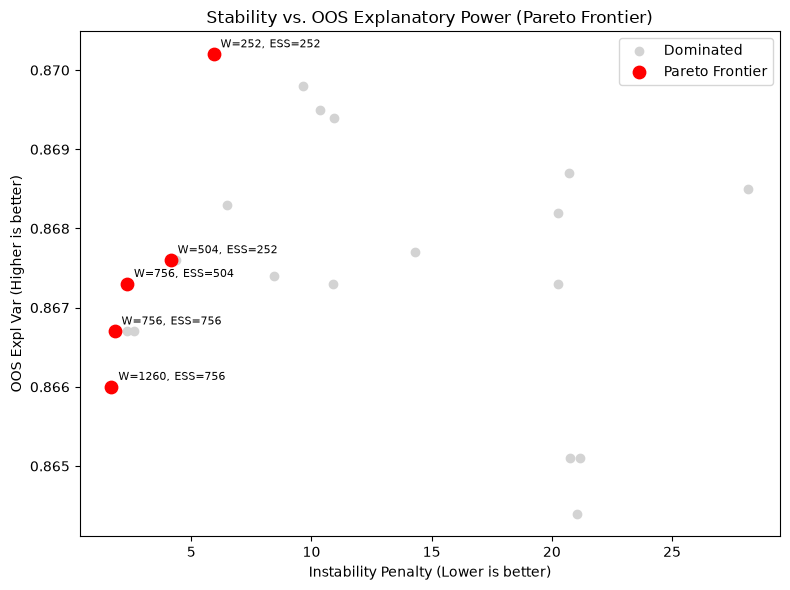

,Window,Target ESS,Implied Decay,In-Sample Expl Var,OOS Expl Var,Overfit Gap,Instability Penalty,Combined Score
0,1260,756,0.99736,0.9459,0.8660,0.0799,1.6794,0.185715
1,756,756,0.99736,0.9483,0.8667,0.0817,1.8096,0.637339
2,756,504,0.99604,0.9482,0.8673,0.0809,2.3269,0.973719
5,504,252,0.99209,0.9497,0.8676,0.0821,4.1441,0.947038
7,252,252,0.99209,0.9515,0.8702,0.0814,5.9287,2.461830


In [42]:
# Display top 10 Pareto-optimal candidates
pareto_candidates = plot_pareto_frontier(optimization_results)
display(pareto_candidates.head(10))